## SUPPORT VECTOR MACHINE

#### 1: Exploratory Data Analysis (EDA)

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv("Pharma_Industry (1).csv")
print(df.head())

   Drug Dosage (mg)  Systolic Blood Pressure (mmHg)  Heart Rate (BPM)  \
0         -0.128538                        0.303280         -1.881849   
1         -1.846188                        2.865142         -0.929511   
2         -1.252393                       -1.541613          0.363632   
3          1.992515                       -1.142779         -0.766657   
4          0.377100                        0.538410         -0.029263   

   Liver Toxicity Index (U/L)  Blood Glucose Level (mg/dL)  Drug Response  
0                    0.258286                    -0.792011              1  
1                    2.866786                    -0.719447              1  
2                   -0.325370                     0.191314              0  
3                    0.975286                    -0.823355              1  
4                    1.896015                    -0.960130              1  


In [3]:
print("Dataset Shape:")
print(df.shape)

Dataset Shape:
(500, 6)


In [4]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Drug Dosage (mg)                500 non-null    float64
 1   Systolic Blood Pressure (mmHg)  500 non-null    float64
 2   Heart Rate (BPM)                500 non-null    float64
 3   Liver Toxicity Index (U/L)      500 non-null    float64
 4   Blood Glucose Level (mg/dL)     500 non-null    float64
 5   Drug Response                   500 non-null    int64  
dtypes: float64(5), int64(1)
memory usage: 23.6 KB
None


In [5]:
print(df.describe())

       Drug Dosage (mg)  Systolic Blood Pressure (mmHg)  Heart Rate (BPM)  \
count        500.000000                      500.000000        500.000000   
mean          -0.037761                        0.214957          0.062871   
std            0.979891                        1.247567          0.971978   
min           -3.019512                       -3.773897         -2.940389   
25%           -0.642003                       -0.565168         -0.648157   
50%           -0.019340                        0.201532          0.027732   
75%            0.641151                        0.951375          0.710774   
max            2.949094                        4.111751          3.193108   

       Liver Toxicity Index (U/L)  Blood Glucose Level (mg/dL)  Drug Response  
count                  500.000000                   500.000000       500.0000  
mean                     0.054398                    -0.171863         0.5200  
std                      0.986001                     0.983765    

In [6]:
print(df.isnull().sum())

Drug Dosage (mg)                  0
Systolic Blood Pressure (mmHg)    0
Heart Rate (BPM)                  0
Liver Toxicity Index (U/L)        0
Blood Glucose Level (mg/dL)       0
Drug Response                     0
dtype: int64


In [7]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


In [8]:
print(df.columns)

Index(['Drug Dosage (mg)', 'Systolic Blood Pressure (mmHg)',
       'Heart Rate (BPM)', 'Liver Toxicity Index (U/L)',
       'Blood Glucose Level (mg/dL)', 'Drug Response'],
      dtype='object')


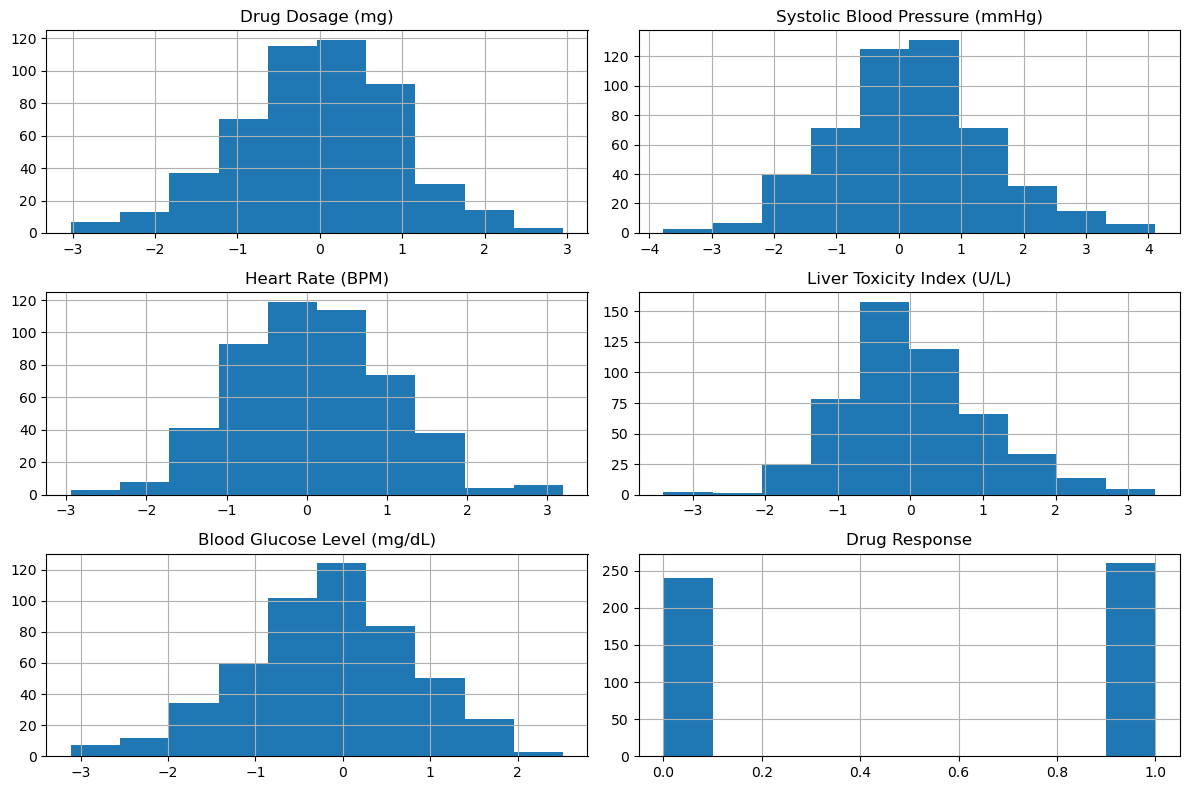

In [9]:
df.hist(figsize=(12,8))
plt.tight_layout()
plt.show()

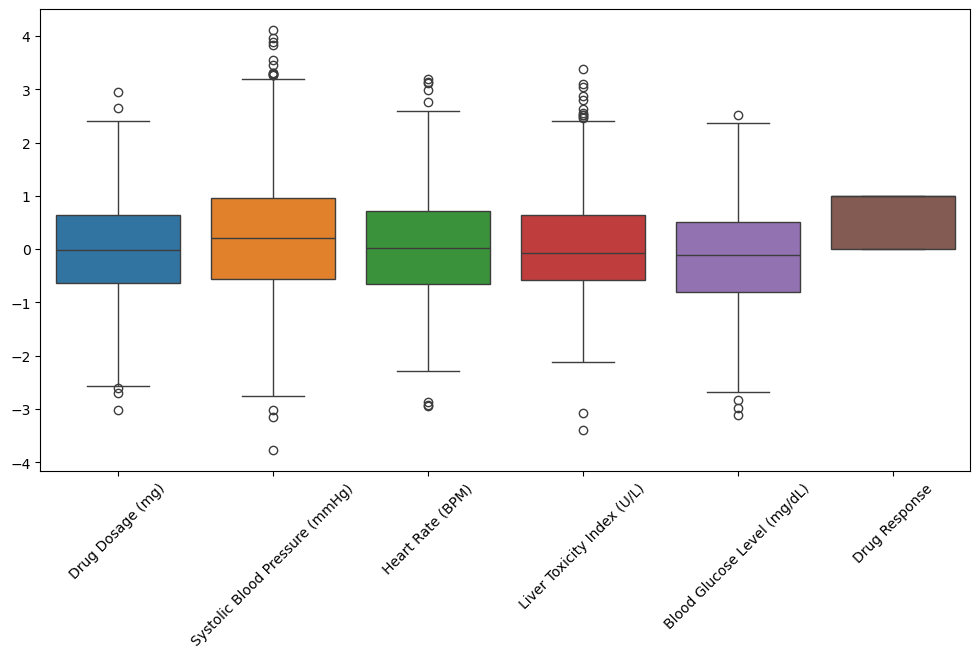

In [10]:
plt.figure(figsize=(12,6))
sns.boxplot(data=df.select_dtypes(include='number'))
plt.xticks(rotation=45)
plt.show()

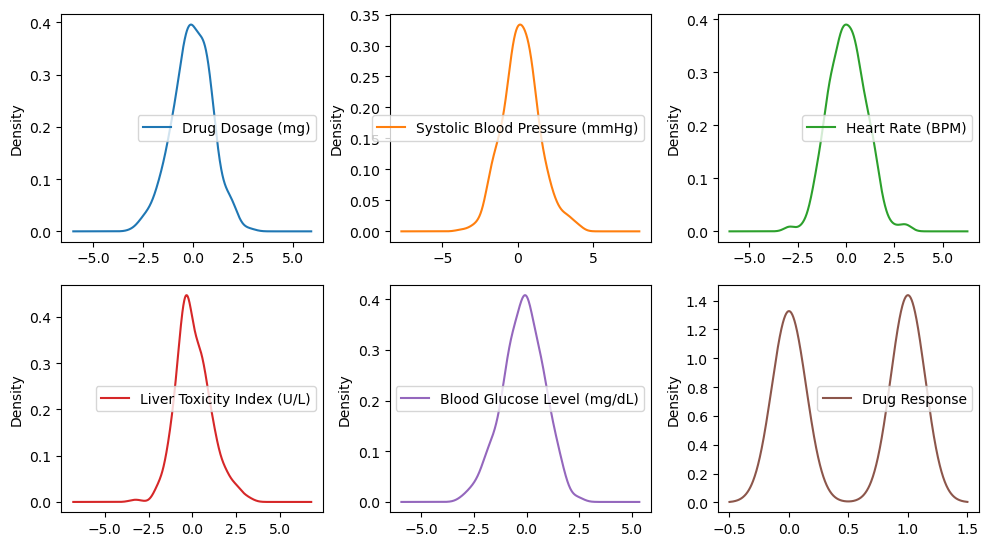

In [11]:
df.select_dtypes(include='number').plot(kind='density',
                                        subplots=True,
                                        layout=(3,3),
                                        figsize=(10,8),
                                        sharex=False)

plt.tight_layout()
plt.show()

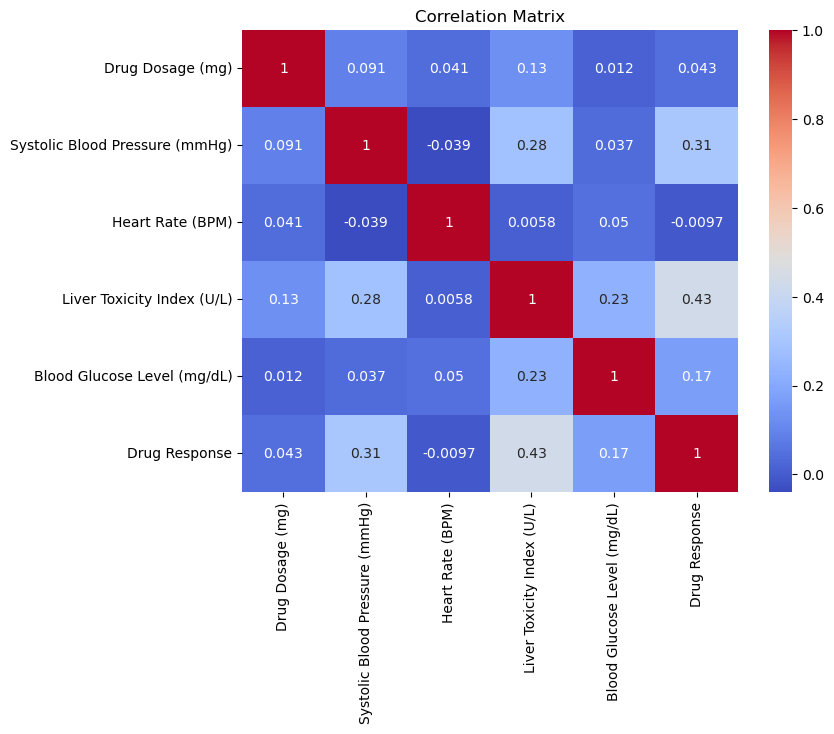

In [12]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr,
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Matrix")
plt.show()

#### 2: Data Preprocessing

In [14]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])
print(df.head())

   Drug Dosage (mg)  Systolic Blood Pressure (mmHg)  Heart Rate (BPM)  \
0         -0.128538                        0.303280         -1.881849   
1         -1.846188                        2.865142         -0.929511   
2         -1.252393                       -1.541613          0.363632   
3          1.992515                       -1.142779         -0.766657   
4          0.377100                        0.538410         -0.029263   

   Liver Toxicity Index (U/L)  Blood Glucose Level (mg/dL)  Drug Response  
0                    0.258286                    -0.792011              1  
1                    2.866786                    -0.719447              1  
2                   -0.325370                     0.191314              0  
3                    0.975286                    -0.823355              1  
4                    1.896015                    -0.960130              1  


In [15]:
print(df.dtypes)

Drug Dosage (mg)                  float64
Systolic Blood Pressure (mmHg)    float64
Heart Rate (BPM)                  float64
Liver Toxicity Index (U/L)        float64
Blood Glucose Level (mg/dL)       float64
Drug Response                       int64
dtype: object


In [18]:
print(df.columns)

Index(['Drug Dosage (mg)', 'Systolic Blood Pressure (mmHg)',
       'Heart Rate (BPM)', 'Liver Toxicity Index (U/L)',
       'Blood Glucose Level (mg/dL)', 'Drug Response'],
      dtype='object')


In [19]:
from sklearn.model_selection import train_test_split

# Features (X) and Target (y)
X = df.drop("Drug Response", axis=1)
y = df["Drug Response"]

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

# Display the shape
print("X_train:", X_train.shape)
print("X_test :", X_test.shape)
print("y_train:", y_train.shape)
print("y_test :", y_test.shape)

X_train: (400, 5)
X_test : (100, 5)
y_train: (400,)
y_test : (100,)


#### 3: Data Visualization

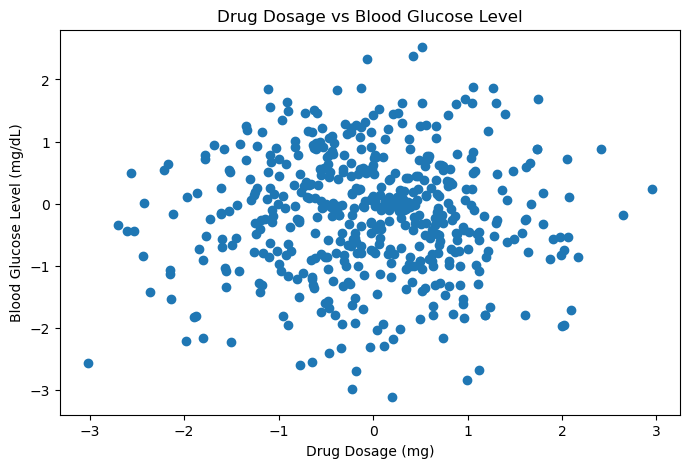

In [20]:
plt.figure(figsize=(8,5))
plt.scatter(df["Drug Dosage (mg)"], df["Blood Glucose Level (mg/dL)"])

plt.xlabel("Drug Dosage (mg)")
plt.ylabel("Blood Glucose Level (mg/dL)")
plt.title("Drug Dosage vs Blood Glucose Level")

plt.show()

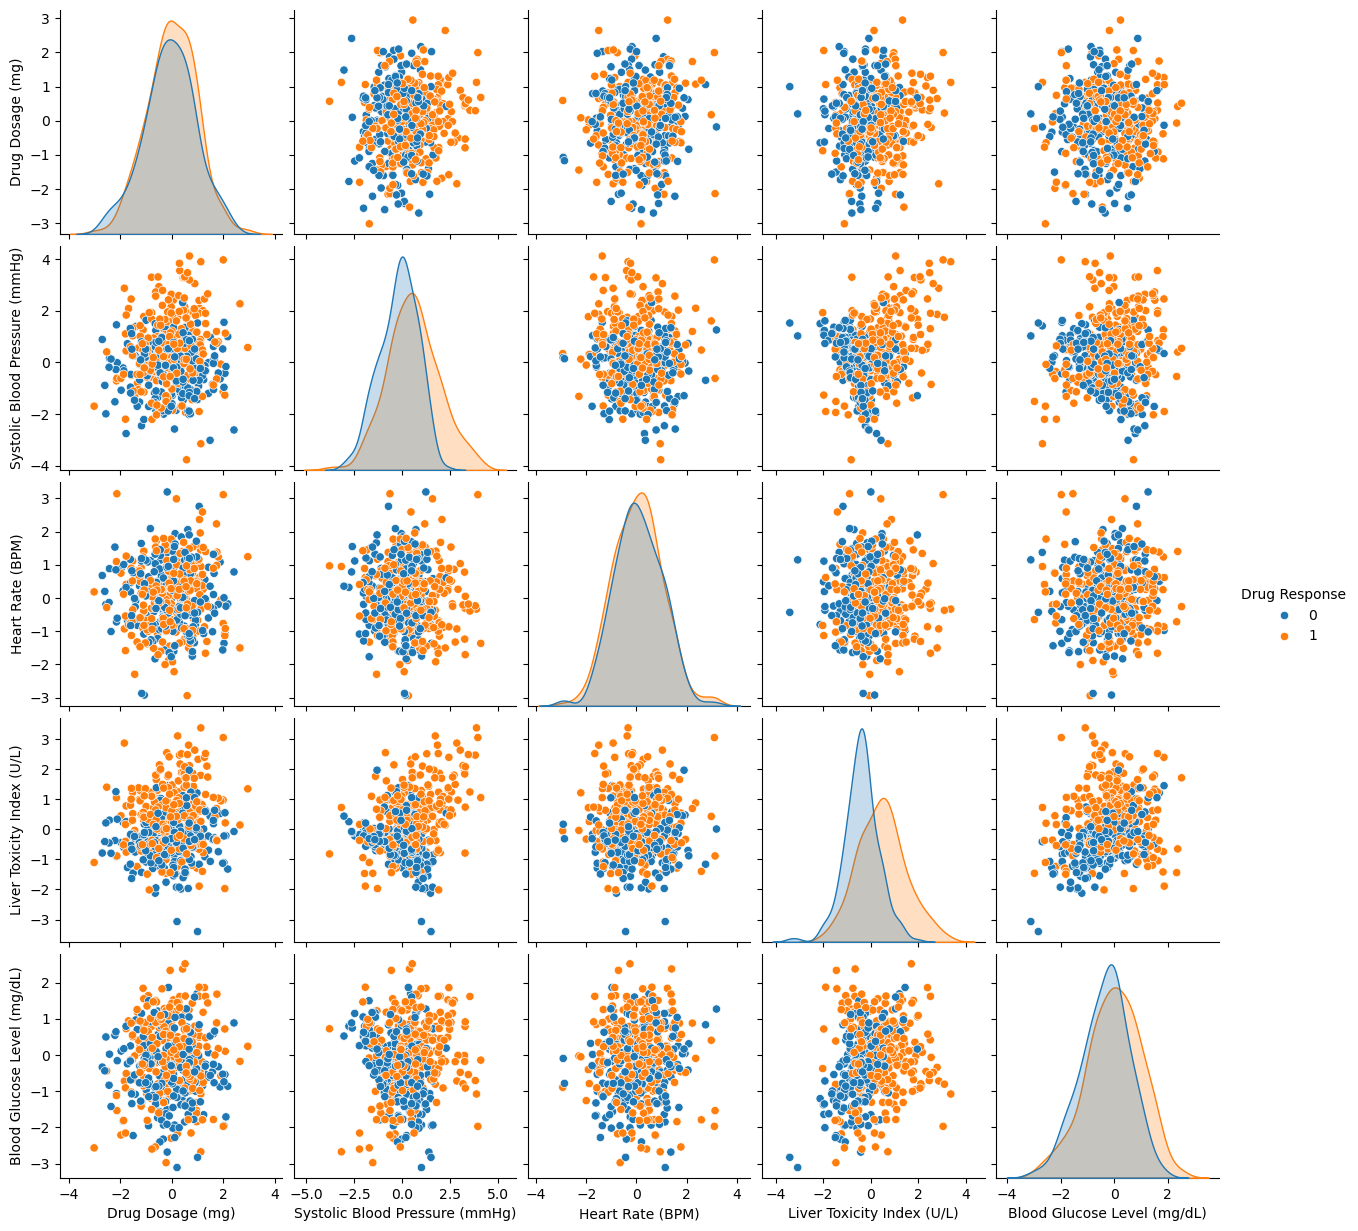

In [23]:
sns.pairplot(df, hue="Drug Response")

plt.show()

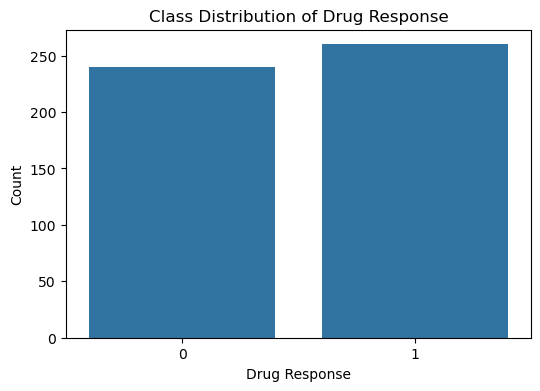

In [24]:
plt.figure(figsize=(6,4))
sns.countplot(x="Drug Response", data=df)

plt.title("Class Distribution of Drug Response")
plt.xlabel("Drug Response")
plt.ylabel("Count")

plt.show()

#### 4: SVM Implementation

In [25]:
from sklearn.svm import SVC
svm_model = SVC(kernel='linear', random_state=42)
print(svm_model)

SVC(kernel='linear', random_state=42)


In [26]:
svm_model.fit(X_train, y_train)
print("SVM model trained successfully.")

SVM model trained successfully.


In [27]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
y_pred = svm_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='weighted')
recall = recall_score(y_test, y_pred, average='weighted')
f1 = f1_score(y_test, y_pred, average='weighted')

print("Accuracy :", accuracy)
print("Precision:", precision)
print("Recall   :", recall)
print("F1-Score :", f1)

Accuracy : 0.78
Precision: 0.7872
Recall   : 0.78
F1-Score : 0.780794861501405


#### 5: Visualization of SVM Results

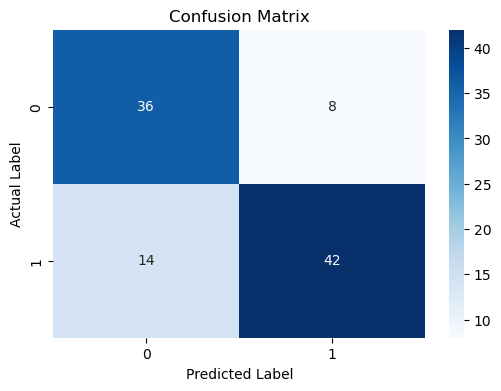

In [28]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")

plt.show()

#### 6: Parameter Tuning and Optimization

In [30]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

svm_linear = SVC(kernel='linear', C=1)
svm_linear.fit(X_train, y_train)
y_pred_linear = svm_linear.predict(X_test)
print("Linear Kernel Accuracy:", accuracy_score(y_test, y_pred_linear))

svm_poly = SVC(kernel='poly', C=1)
svm_poly.fit(X_train, y_train)
y_pred_poly = svm_poly.predict(X_test)
print("Polynomial Kernel Accuracy:", accuracy_score(y_test, y_pred_poly))

svm_rbf = SVC(kernel='rbf', C=1)
svm_rbf.fit(X_train, y_train)
y_pred_rbf = svm_rbf.predict(X_test)
print("RBF Kernel Accuracy:", accuracy_score(y_test, y_pred_rbf))

Linear Kernel Accuracy: 0.78
Polynomial Kernel Accuracy: 0.69
RBF Kernel Accuracy: 0.82


In [31]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

for c in [0.1, 1, 10]:
    model = SVC(kernel='rbf', C=c)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    print("C =", c)
    print("Accuracy =", accuracy_score(y_test, y_pred))

C = 0.1
Accuracy = 0.78
C = 1
Accuracy = 0.82
C = 10
Accuracy = 0.78


#### 7: Comparison and Analysis

In [32]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

linear_model = SVC(kernel='linear', random_state=42)
linear_model.fit(X_train, y_train)
linear_pred = linear_model.predict(X_test)
linear_acc = accuracy_score(y_test, linear_pred)

poly_model = SVC(kernel='poly', random_state=42)
poly_model.fit(X_train, y_train)
poly_pred = poly_model.predict(X_test)
poly_acc = accuracy_score(y_test, poly_pred)

rbf_model = SVC(kernel='rbf', random_state=42)
rbf_model.fit(X_train, y_train)
rbf_pred = rbf_model.predict(X_test)
rbf_acc = accuracy_score(y_test, rbf_pred)

print("Linear Kernel Accuracy     :", linear_acc)
print("Polynomial Kernel Accuracy :", poly_acc)
print("RBF Kernel Accuracy        :", rbf_acc)

Linear Kernel Accuracy     : 0.78
Polynomial Kernel Accuracy : 0.69
RBF Kernel Accuracy        : 0.82


In [ ]:
Strengths of SVM

SVM performed well on the dataset and classified the drug response accurately.
It works effectively with numerical features such as drug dosage, blood pressure, heart rate, liver toxicity index, and blood glucose level.
The scatter plots and pair plots showed that some classes are separable, making SVM a suitable classifier.
SVM is effective even when there are multiple features in the dataset.

In [ ]:
Weaknesses of SVM

SVM performance depends on selecting an appropriate kernel and tuning parameters such as C.
If the classes overlap significantly, SVM may produce some misclassifications.
SVM can become computationally expensive for very large datasets.
It is less interpretable than simple models such as Decision Trees.

In [ ]:
Practical Implications of SVM in Real-World Classification Tasks

SVM is widely used for classification problems because it provides high accuracy and works well with both linear and non-linear data.
In healthcare, SVM can be used to predict diseases and classify patient conditions based on medical data.
In finance, it helps detect fraudulent transactions and assess credit risk.
In email services, SVM is used for spam email detection.
In image recognition, it classifies images into different categories, such as face recognition and object detection.
SVM performs well on datasets with many features and is effective when classes are clearly separable.
However, SVM requires proper selection of the kernel and hyperparameters, and it may be slower on very large datasets.